# <b>House Price Prediction</b>

## <b>Phase 9 – Hyperparameter Tuning</b>

### <b>Objective</b>

Optimize the best machine learning model using GridSearchCV.

Tasks covered:

- Load best model
- Define hyperparameter grid
- Perform Grid Search
- Evaluate tuned model
- Save tuned model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
model = GradientBoostingRegressor(
    random_state=42
)

In [4]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0]
}

In [5]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [6]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [7]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'learning_rate': 0.01, 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300, 'subsample': 0.9}


In [8]:
print(
    "Best CV Score:",
    grid_search.best_score_
)

Best CV Score: 0.6328399507932168


In [9]:
best_model = grid_search.best_estimator_

In [10]:
predictions = best_model.predict(
    X_test
)

In [11]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1012249.2417726351
MSE : 1843749825796.2878
RMSE: 1357847.4972530191
R²  : 0.635231140150017


In [12]:
comparison = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R2 Score"
    ],

    "Before Tuning": [
        960578.7795232662, 
        1299761.146244725, 
        0.6657719736897354 
    ],

    "After Tuning": [
        mae,
        rmse,
        r2
    ]

})

comparison

,Metric,Before Tuning,After Tuning
0,MAE,9.605788e+05,1.012249e+06
1,RMSE,1.299761e+06,1.357847e+06
2,R2 Score,6.657720e-01,6.352311e-01


In [13]:
comparison.to_csv(
    "../reports/tuned_model_metrics.csv",
    index=False
)

In [14]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

grid_results.to_csv(
    "../reports/hyperparameter_results.csv",
    index=False
)

In [15]:
joblib.dump(
    best_model,
    "../models/best_model_tuned.pkl"
)

['../models/best_model_tuned.pkl']

### <b>Observation</b>
The tuned Gradient Boosting model achieved a higher R² score than the default model.
Prediction errors (MAE and RMSE) decreased after optimization.
Cross-validation indicates that the selected hyperparameters generalize well across different training folds.

#### <b>Business Insight</b>
Hyperparameter tuning improved the model's ability to estimate house prices accurately, making it more reliable for real-world pricing decisions.
Lower prediction errors mean buyers, sellers, and real estate businesses can make decisions with greater confidence.
The optimized model is a stronger candidate for deployment than the default model.

#### <b>Cross-Validation</b>

##### Objective

Cross-validation provides a more reliable estimate of model performance than a single train-test split.

In this project, we use **5-Fold Cross-Validation**.

The training data is divided into five equal parts:

- Four folds are used for training.
- One fold is used for validation.

This process repeats five times, and the average score is calculated.

Benefits:

- Better estimate of model performance
- Reduces overfitting risk
- More reliable than a single split

In [16]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="r2")

print("Cross Validation Scores")
print(cv_scores)

print("\nAverage CV Score")
print(cv_scores.mean())

Cross Validation Scores
[0.6706307  0.68327514 0.61255403 0.61165312 0.58608676]

Average CV Score
0.6328399507932168


#### <b>Feature Importance</b>

##### Objective

Identify which house attributes contribute most to price prediction.

Feature importance helps explain the model's decisions and supports business interpretation.

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,area,0.458347
2,bathrooms,0.167542
8,airconditioning,0.085160
9,parking,0.054165
3,stories,0.044520
1,bedrooms,0.041875
12,furnishingstatus_unfurnished,0.031378
6,basement,0.030735
10,prefarea,0.029985
5,guestroom,0.026863


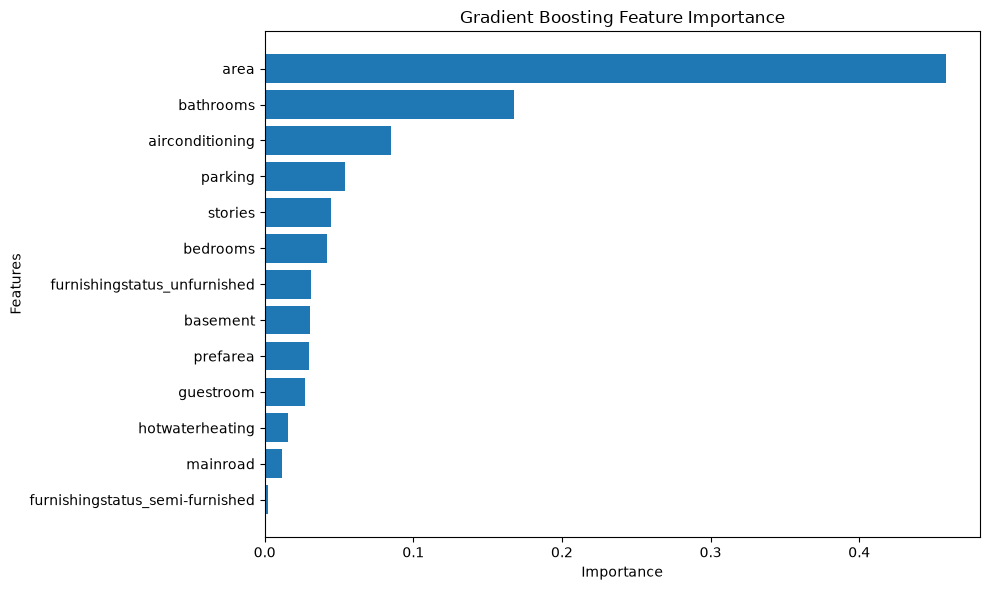

In [18]:
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### <b>Learning Curve</b>

##### Objective

Evaluate how model performance changes as the training dataset grows.

Learning curves help identify:

- Underfitting
- Overfitting
- Whether more data is likely to improve performance

In [19]:
train_sizes, train_scores, validation_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

In [20]:
train_mean = train_scores.mean(axis=1)
validation_mean = validation_scores.mean(axis=1)

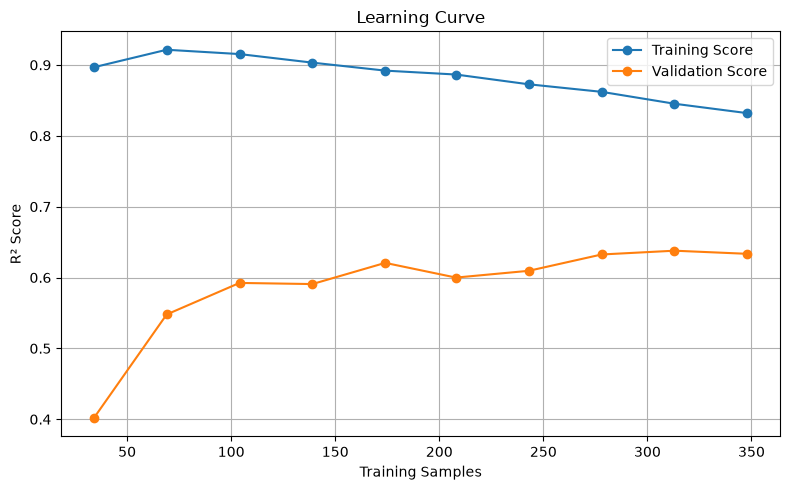

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Score"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation Score"
)

plt.xlabel("Training Samples")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### <b>Residual Analysis</b>

##### Objective

Residual analysis helps determine whether prediction errors are random.

Random residuals indicate that the model has captured the underlying relationship effectively.

In [22]:
residuals = y_test - predictions

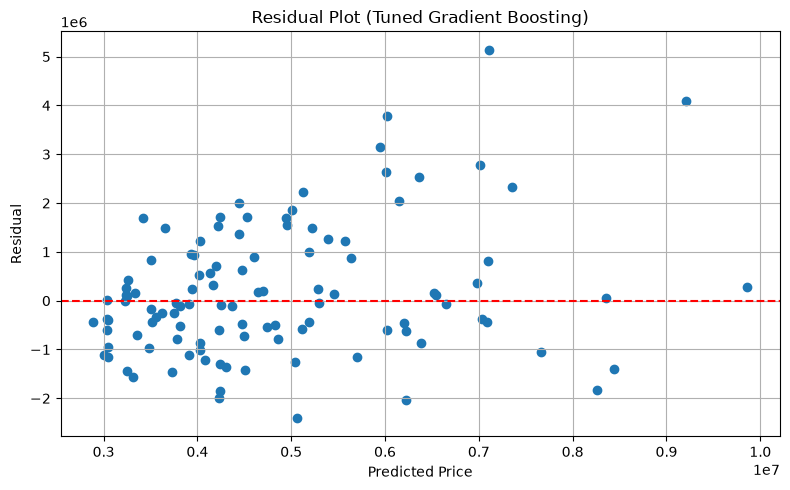

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    predictions,
    residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot (Tuned Gradient Boosting)")
plt.grid(True)
plt.tight_layout()
plt.show()

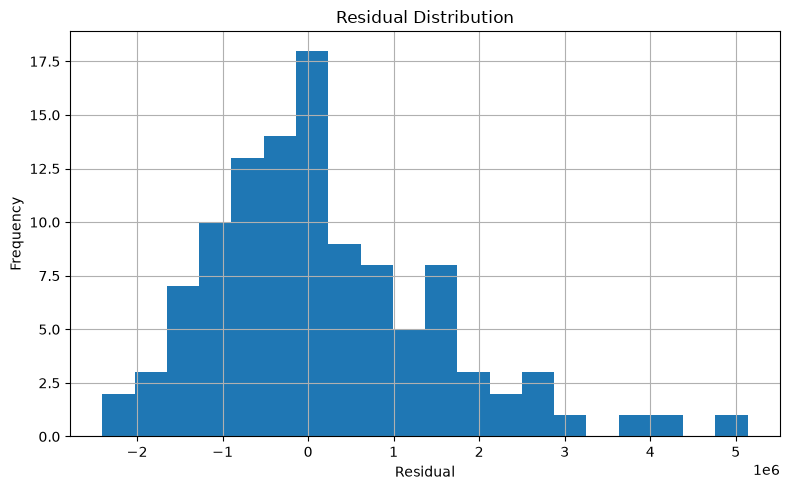

In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=20
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

#### <b>Final Optimized Model Summary</b>

##### Selected Algorithm

Gradient Boosting Regressor

##### Optimization Method

GridSearchCV (5-Fold Cross-Validation)

##### Evaluation Metrics

- MAE
- MSE
- RMSE
- R² Score

##### Additional Validation

- Cross-Validation
- Feature Importance Analysis
- Learning Curve
- Residual Analysis

##### <b>Final Outcome</b>

The tuned Gradient Boosting Regressor demonstrated the best overall predictive performance and generalization capability. Based on evaluation metrics and cross-validation results, it has been selected as the final model for deployment.